In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

df = pd.read_csv(r"C:/Users/USA/3mtt/3mmt-project/data_2.0.csv")
print(df.shape)
display(df.head())


(4572, 4)


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


Exploring the data set to find missing values, duplicates to ensure data quality before analysis

In [20]:
# Basic information
print("=== Dataset Information ===")
df.info()

print("\n=== Summary Statistics ===")
display(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Number of Duplicates ===")
print(df.duplicated().sum())

# Handle missing values if any
df = df.dropna()
print("\nData cleaned. New shape:", df.shape)

=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB

=== Summary Statistics ===


,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751



=== Missing Values ===
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

=== Number of Duplicates ===
0

Data cleaned. New shape: (4546, 4)


Visualizing the relationship between marketing spend on TV, Radio and Social media vs sales. To understand the relationships between them.

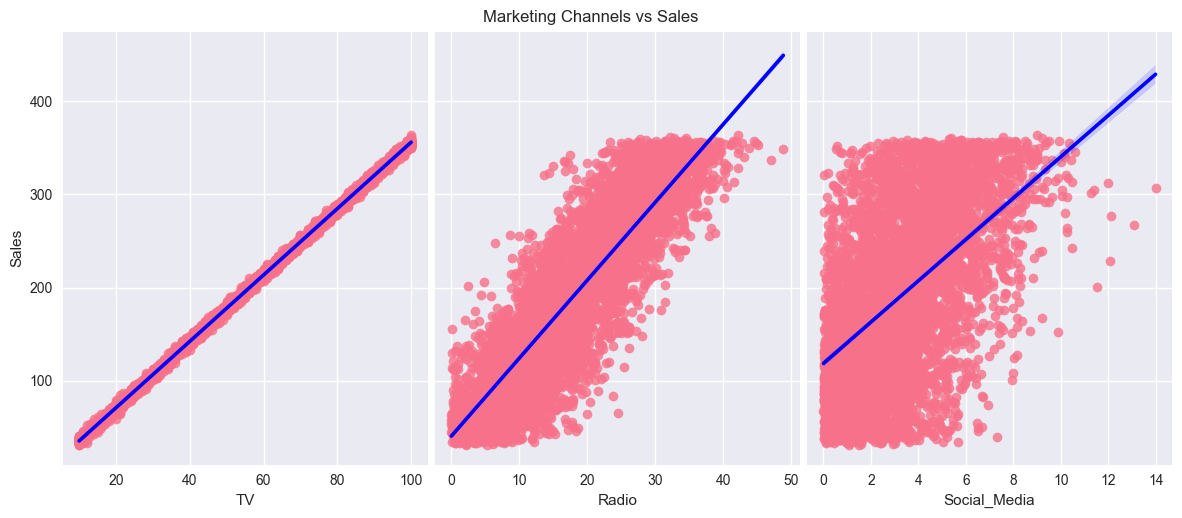

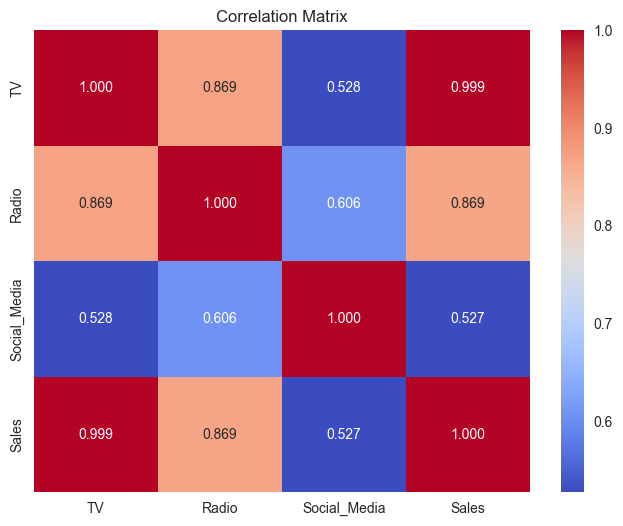

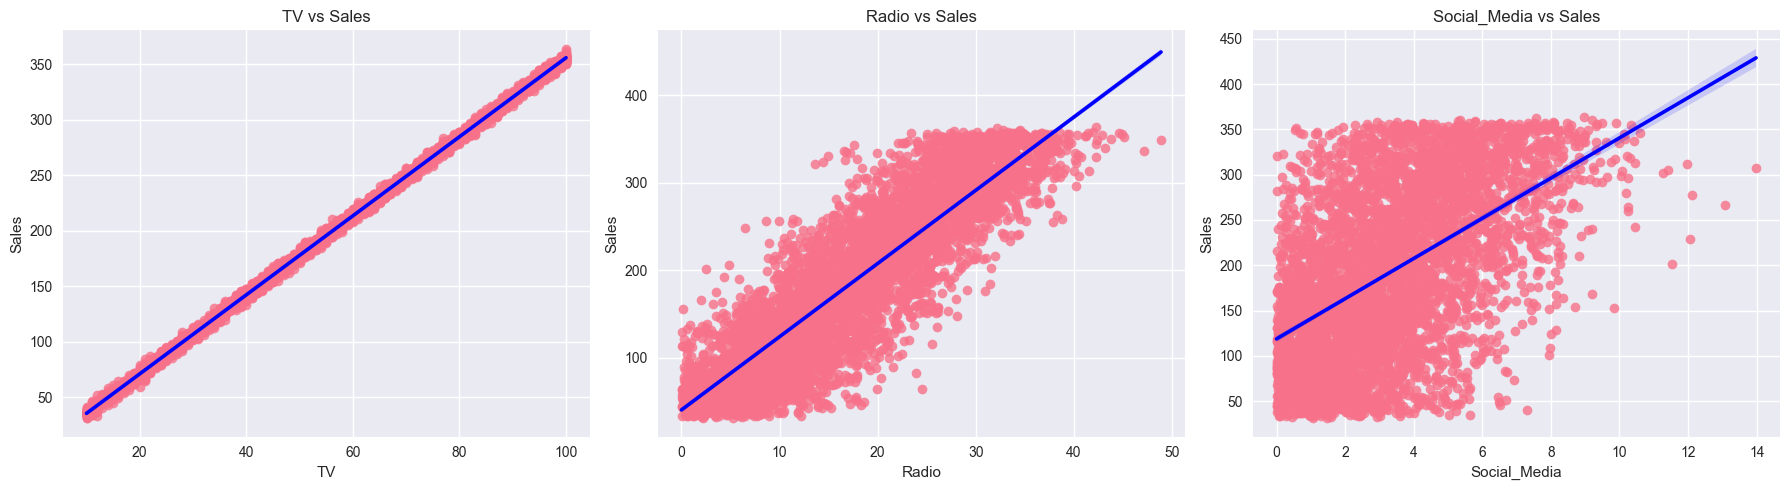

In [21]:
# Pairplot with regression lines
sns.pairplot(df, x_vars=['TV', 'Radio', 'Social_Media'], y_vars='Sales', 
             height=5, aspect=0.8, kind='reg', plot_kws={'line_kws':{'color': 'blue'}})
plt.suptitle('Marketing Channels vs Sales', y=1.02)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation Matrix')
plt.show()

# Individual scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['TV', 'Radio', 'Social_Media']):
    sns.regplot(x=col, y='Sales', data=df, ax=axes[i], line_kws={'color': 'blue'})
    axes[i].set_title(f'{col} vs Sales')
plt.tight_layout()
plt.show()

Identifying the Market spend(TV,radio,Social_Media) with the most linear relationship with Sales.

In [23]:
correlations = df[['TV', 'Radio', 'Social_Media', 'Sales']].corr()['Sales'].sort_values(ascending=False)
print("Correlation with Sales:\n")
print(correlations)

# Select best predictor
best_predictor = correlations.index[1] # Skip 'Sales'
print(f"\n Best independent variable for prediction: {best_predictor}") 

Correlation with Sales:

Sales           1.000000
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64

 Best independent variable for prediction: TV


OLS regression Results:
Sales = (3.5615 X TV) - 0.1325$$ just like y = mx + c

In [25]:
# Prepare variables
X = df[[best_predictor]]
y = df['Sales']

# Add constant (intercept)
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Display results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Mon, 08 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:10:20   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

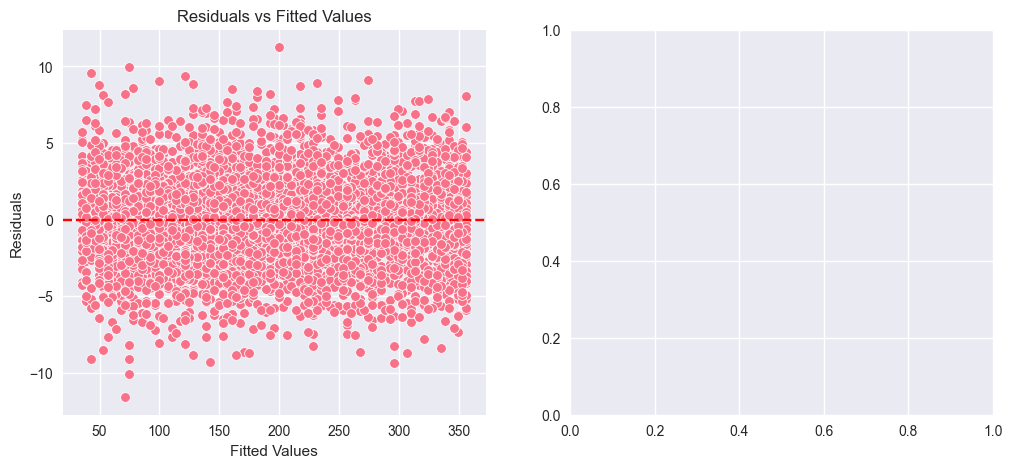

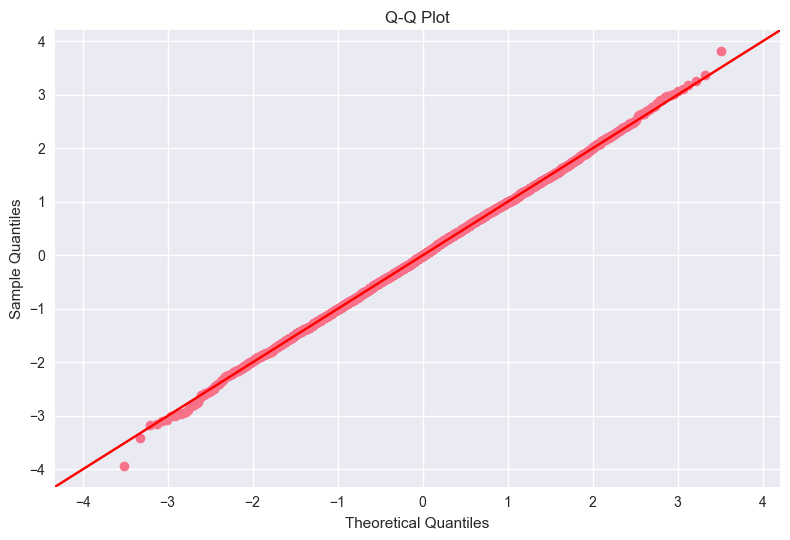

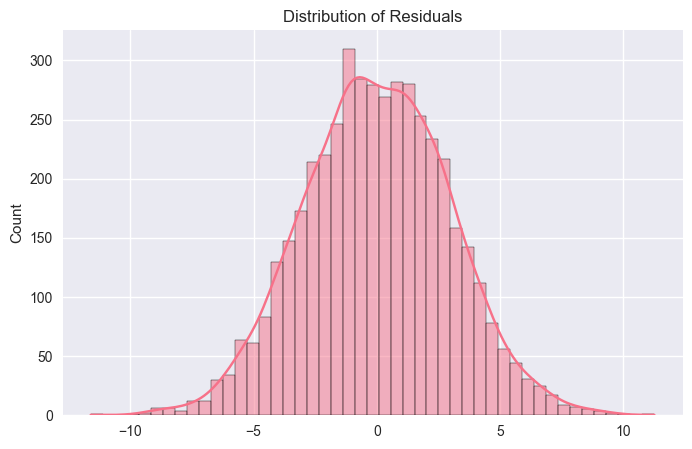

In [26]:
fitted = model.fittedvalues
residuals = model.resid

# Residuals vs Fitted
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')

# Q-Q Plot
plt.subplot(1, 2, 2)
sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot')

plt.tight_layout()
plt.show()

# Residual distribution
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.show()

 

The statistical outputs (R-squared, coefficients, p-values) are translated into actionable marketing insights.

In [27]:
print("=== FINAL MODEL INTERPRETATION ===\n")

print(f"• R-squared: {model.rsquared:.4f} → The model explains {model.rsquared*100:.1f}% of the variation in Sales.")

coef = model.params[best_predictor]
pvalue = model.pvalues[best_predictor]

print(f"• For every $1 increase in **{best_predictor}** spending, Sales increase by **${coef:.2f}** on average.")

if pvalue < 0.05:
    print(f"• The result is statistically significant (p-value = {pvalue:.4f})")
else:
    print(f"• The result is NOT statistically significant (p-value = {pvalue:.4f})")

print("\n=== BUSINESS RECOMMENDATION ===")
print(f"**Allocate more marketing budget to {best_predictor}** as it demonstrates the strongest positive impact on Sales.")
print("This channel offers the highest ROI and should be prioritized in future campaigns.")

=== FINAL MODEL INTERPRETATION ===

• R-squared: 0.9990 → The model explains 99.9% of the variation in Sales.
• For every $1 increase in **TV** spending, Sales increase by **$3.56** on average.
• The result is statistically significant (p-value = 0.0000)

=== BUSINESS RECOMMENDATION ===
**Allocate more marketing budget to TV** as it demonstrates the strongest positive impact on Sales.
This channel offers the highest ROI and should be prioritized in future campaigns.
